In [65]:
import scanpy as sc
import matplotlib.pyplot as plt
import warnings
import pandas as pd
import numpy as np
warnings.simplefilter("ignore")
import omicverse as ov
import scvelo as scv
ov.plot_set()

Dependency error: The 'phate>=1.0' distribution was not found and is required by the application


In [66]:
sc.logging.print_header()

scanpy==1.10.4 anndata==0.11.3 umap==0.5.7 numpy==1.26.4 scipy==1.15.3 pandas==2.2.3 scikit-learn==1.6.1 statsmodels==0.14.4 igraph==0.11.8 pynndescent==0.5.13


In [67]:
adata = sc.read("/home/lugli/spuccio/Projects/SP039/GBmap/TcellCD8_Data.h5ad")

In [68]:
adata = adata.raw.to_adata()

In [69]:
ov.utils.cluster(adata,method='leiden',resolution=0.4)

running Leiden clustering
    finished: found 11 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:05)


# Hallmarks

In [70]:
pathway_dict=ov.utils.geneset_prepare('/home/lugli/spuccio/Projects/SP039/New_2024/MSigDB/h.all.v2024.1.Hs.symbols.gmt',organism='Human')

##Assest all pathways
adata_aucs=ov.single.pathway_aucell_enrichment(adata,
                                                  pathways_dict=pathway_dict,
                                                  num_workers=8)

adata_aucs.obs=adata[adata_aucs.obs.index].obs
adata_aucs.obsm=adata[adata_aucs.obs.index].obsm
adata_aucs.obsp=adata[adata_aucs.obs.index].obsp
adata_aucs

In [71]:
#adata_aucs.write_h5ad('./GO_Biological_Process_2021_auce.h5ad',compression='gzip')

In [72]:
res=ov.single.pathway_enrichment(adata,pathways_dict=pathway_dict,organism='Human',cutoff=0.05,logfc_threshold=1,
                                     group_by='leiden',plot=False)

In [73]:
res['cluster2'] = res['Cluster'].astype(int)

In [74]:
res = res.sort_values(['cluster2'])

In [75]:
del res['cluster2']

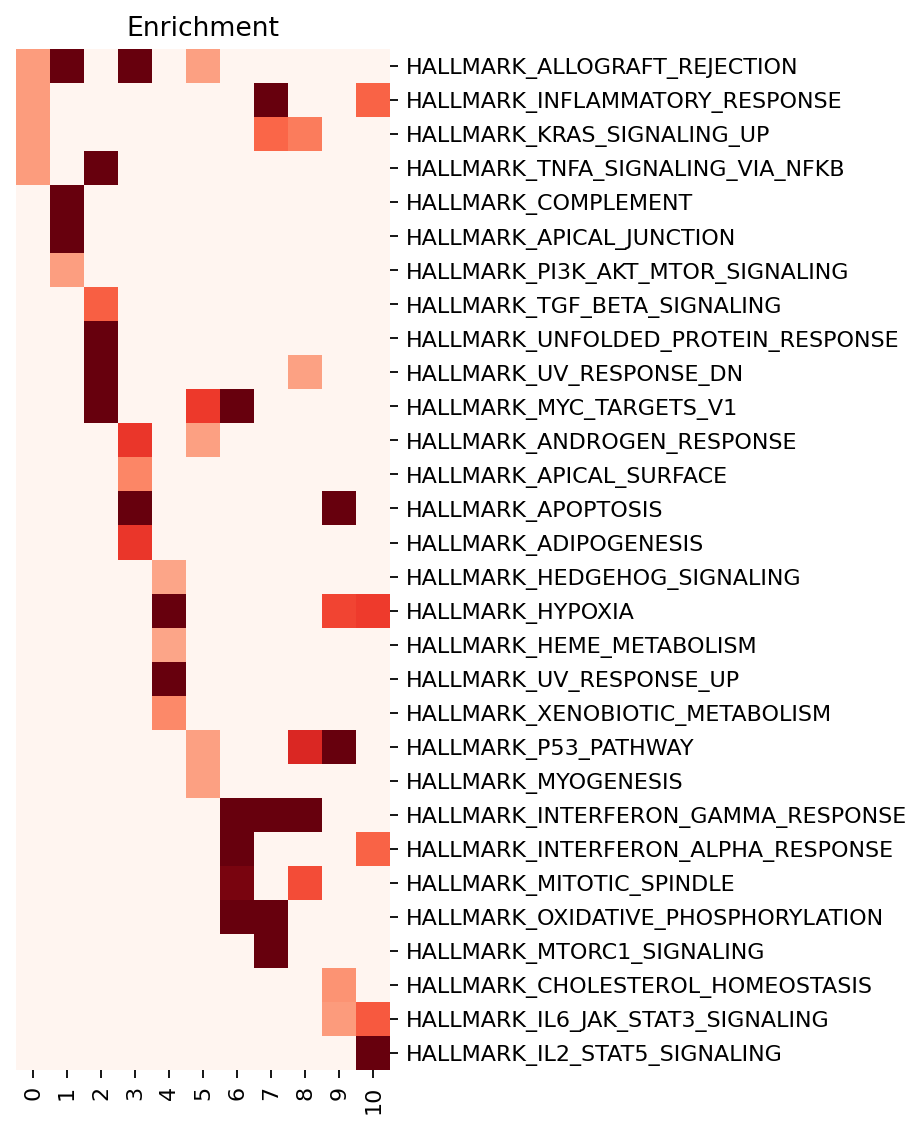

In [76]:
import matplotlib as plt
ax=ov.single.pathway_enrichment_plot(res,plot_title='Enrichment',cmap='Reds',
                                         xticklabels=True,cbar=False,square=True,vmax=10,
                                         yticklabels=True,cbar_kws={'label': '-log10(qvalue)','shrink': 0.5,})
ax.grid(False)

In [77]:
# Assuming Res is your DataFrame
output_file = "/home/lugli/spuccio/Projects/SP039/New_2024/Hallmarks.xlsx"

with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
    for cluster, df_cluster in res.groupby("Cluster"):
        # Make sure sheet name is valid
        sheet_name = f"cluster_{str(cluster)}"
        df_cluster.to_excel(writer, sheet_name=sheet_name, index=False)

print(f"Custom enrichment results saved to {output_file}")


Custom enrichment results saved to /home/lugli/spuccio/Projects/SP039/New_2024/Hallmarks.xlsx


# Reactome

In [78]:
pathway_dict=ov.utils.geneset_prepare('/home/lugli/spuccio/Projects/SP039/New_2024/MSigDB/c2.cp.reactome.v2024.1.Hs.symbols.gmt',organism='Human')

In [79]:
res=ov.single.pathway_enrichment(adata,pathways_dict=pathway_dict,organism='Human',cutoff=0.05,logfc_threshold=1,
                                     group_by='leiden',plot=False)

In [80]:
res['cluster2'] = res['Cluster'].astype(int)
res = res.sort_values(['cluster2'])
del res['cluster2']

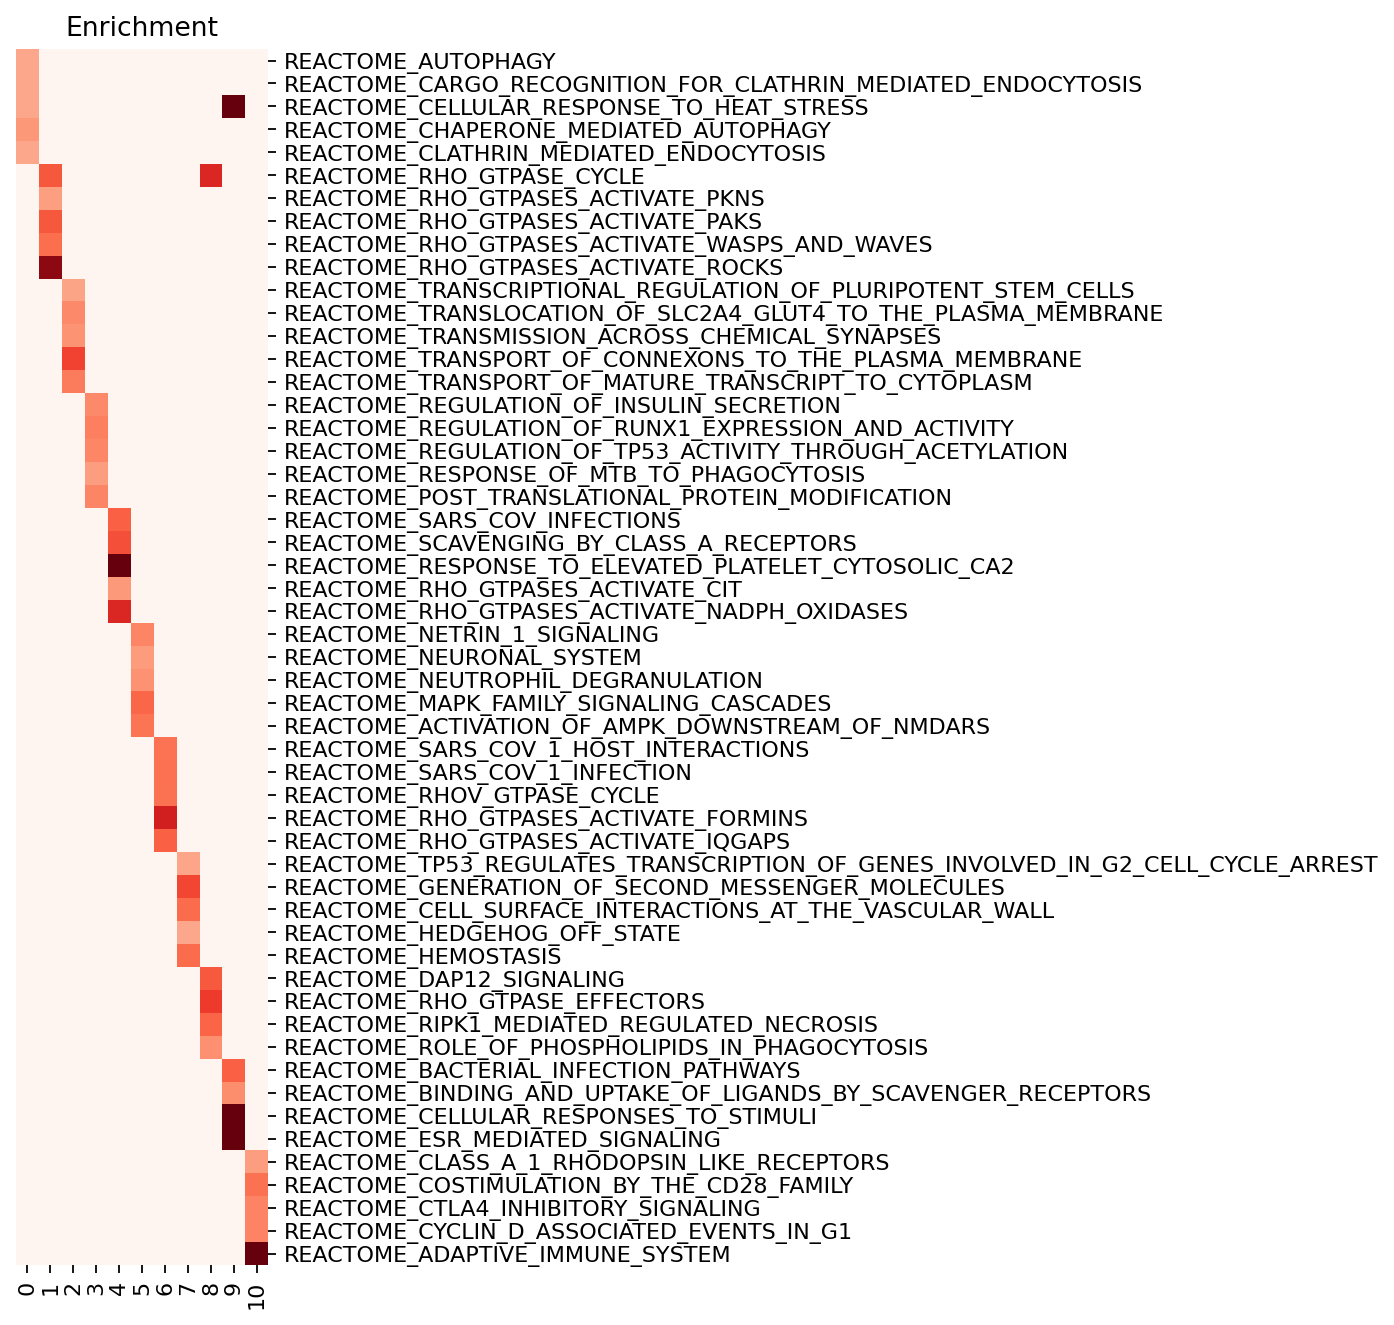

In [81]:
import matplotlib as plt
ax=ov.single.pathway_enrichment_plot(res,plot_title='Enrichment',cmap='Reds',
                                         xticklabels=True,cbar=False,square=True,vmax=10,
                                         yticklabels=True,cbar_kws={'label': '-log10(qvalue)','shrink': 0.5,})
ax.grid(False)

In [82]:
# Assuming Res is your DataFrame
output_file = "/home/lugli/spuccio/Projects/SP039/New_2024/Reactome.xlsx"

with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
    for cluster, df_cluster in res.groupby("Cluster"):
        # Make sure sheet name is valid
        sheet_name = f"cluster_{str(cluster)}"
        df_cluster.to_excel(writer, sheet_name=sheet_name, index=False)

print(f"Custom enrichment results saved to {output_file}")


Custom enrichment results saved to /home/lugli/spuccio/Projects/SP039/New_2024/Reactome.xlsx


# KEGG

In [83]:
pathway_dict=ov.utils.geneset_prepare('/home/lugli/spuccio/Projects/SP039/New_2024/MSigDB/c2.cp.kegg_legacy.v2024.1.Hs.symbols.gmt',organism='Human')


In [84]:
res=ov.single.pathway_enrichment(adata,pathways_dict=pathway_dict,organism='Human',cutoff=0.05,logfc_threshold=1,
                                     group_by='leiden',plot=False)

In [85]:
res['cluster2'] = res['Cluster'].astype(int)
res = res.sort_values(['cluster2'])
del res['cluster2']

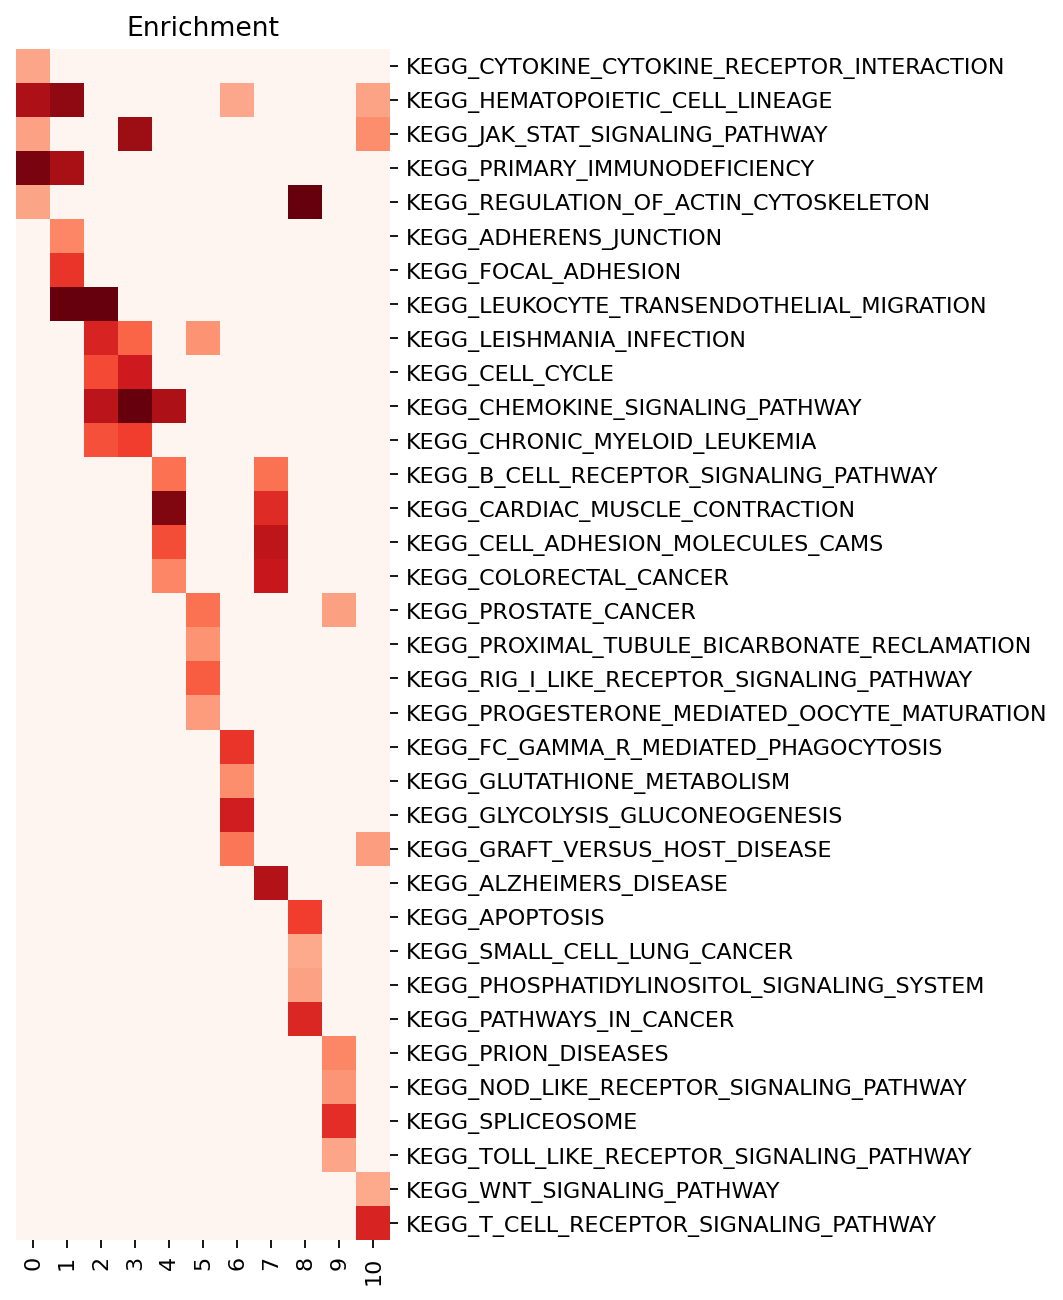

In [86]:
import matplotlib as plt
ax=ov.single.pathway_enrichment_plot(res,plot_title='Enrichment',cmap='Reds',
                                         xticklabels=True,cbar=False,square=True,vmax=10,
                                         yticklabels=True,cbar_kws={'label': '-log10(qvalue)','shrink': 0.5,})
ax.grid(False)

In [87]:
# Assuming Res is your DataFrame
output_file = "/home/lugli/spuccio/Projects/SP039/New_2024/Kegg.xlsx"

with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
    for cluster, df_cluster in res.groupby("Cluster"):
        # Make sure sheet name is valid
        sheet_name = f"cluster_{str(cluster)}"
        df_cluster.to_excel(writer, sheet_name=sheet_name, index=False)

print(f"Custom enrichment results saved to {output_file}")


Custom enrichment results saved to /home/lugli/spuccio/Projects/SP039/New_2024/Kegg.xlsx


# Biocarta

In [88]:
pathway_dict=ov.utils.geneset_prepare('/home/lugli/spuccio/Projects/SP039/New_2024/MSigDB/c2.cp.biocarta.v2024.1.Hs.symbols.gmt',organism='Human')


In [89]:
res=ov.single.pathway_enrichment(adata,pathways_dict=pathway_dict,organism='Human',cutoff=0.05,logfc_threshold=1,
                                     group_by='leiden',plot=False)

In [90]:
res['cluster2'] = res['Cluster'].astype(int)
res = res.sort_values(['cluster2'])
del res['cluster2']

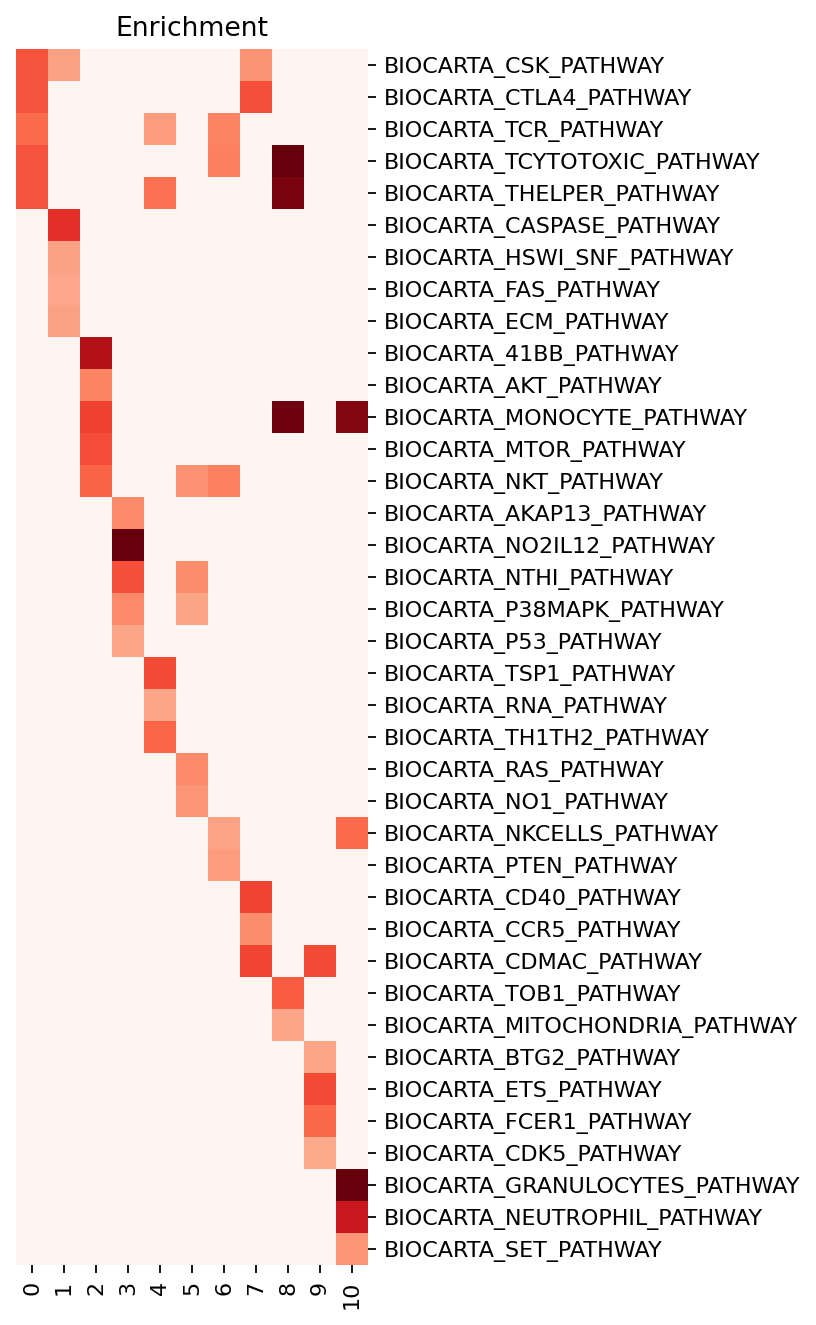

In [91]:
ax=ov.single.pathway_enrichment_plot(res,plot_title='Enrichment',cmap='Reds',
                                         xticklabels=True,cbar=False,square=True,vmax=10,
                                         yticklabels=True,cbar_kws={'label': '-log10(qvalue)','shrink': 0.5,})
ax.grid(False)

In [92]:
# Assuming Res is your DataFrame
output_file = "/home/lugli/spuccio/Projects/SP039/New_2024/Biocarta.xlsx"

with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
    for cluster, df_cluster in res.groupby("Cluster"):
        # Make sure sheet name is valid
        sheet_name = f"cluster_{str(cluster)}"
        df_cluster.to_excel(writer, sheet_name=sheet_name, index=False)

print(f"Custom enrichment results saved to {output_file}")


Custom enrichment results saved to /home/lugli/spuccio/Projects/SP039/New_2024/Biocarta.xlsx


# GO Molecular Function

In [93]:
pathway_dict=ov.utils.geneset_prepare('/home/lugli/spuccio/Projects/SP039/New_2024/MSigDB/c5.go.mf.v2024.1.Hs.symbols.gmt',organism='Human')


In [94]:
res=ov.single.pathway_enrichment(adata,pathways_dict=pathway_dict,organism='Human',cutoff=0.05,logfc_threshold=1,
                                     group_by='leiden',plot=False)

In [95]:
res['cluster2'] = res['Cluster'].astype(int)
res = res.sort_values(['cluster2'])
del res['cluster2']

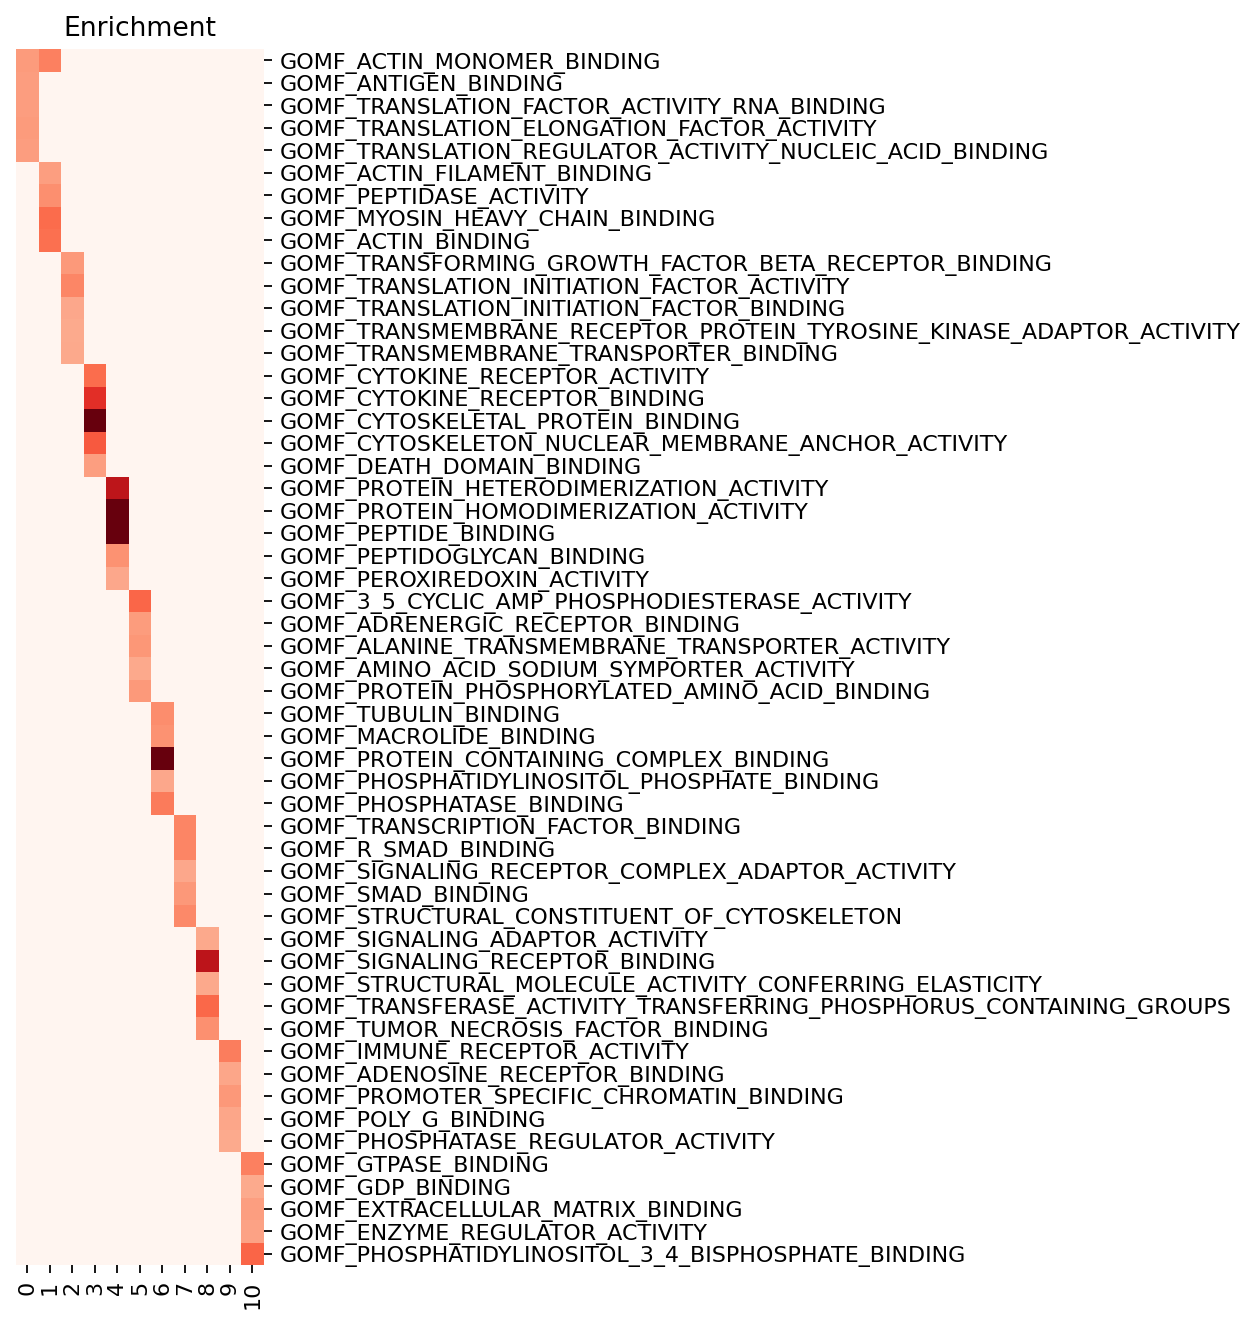

In [96]:
ax=ov.single.pathway_enrichment_plot(res,plot_title='Enrichment',cmap='Reds',
                                         xticklabels=True,cbar=False,square=True,vmax=10,
                                         yticklabels=True,cbar_kws={'label': '-log10(qvalue)','shrink': 0.5,})
ax.grid(False)

In [97]:
# Assuming Res is your DataFrame
output_file = "/home/lugli/spuccio/Projects/SP039/New_2024/go_mf.xlsx"

with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
    for cluster, df_cluster in res.groupby("Cluster"):
        # Make sure sheet name is valid
        sheet_name = f"cluster_{str(cluster)}"
        df_cluster.to_excel(writer, sheet_name=sheet_name, index=False)

print(f"Custom enrichment results saved to {output_file}")


Custom enrichment results saved to /home/lugli/spuccio/Projects/SP039/New_2024/go_mf.xlsx


# GO Biological Process

In [98]:
pathway_dict=ov.utils.geneset_prepare('/home/lugli/spuccio/Projects/SP039/New_2024/MSigDB/c5.go.bp.v2024.1.Hs.symbols.gmt',organism='Human')


In [99]:
res=ov.single.pathway_enrichment(adata,pathways_dict=pathway_dict,organism='Human',cutoff=0.05,logfc_threshold=1,
                                     group_by='leiden',plot=False)

In [100]:
res['cluster2'] = res['Cluster'].astype(int)
res = res.sort_values(['cluster2'])
del res['cluster2']

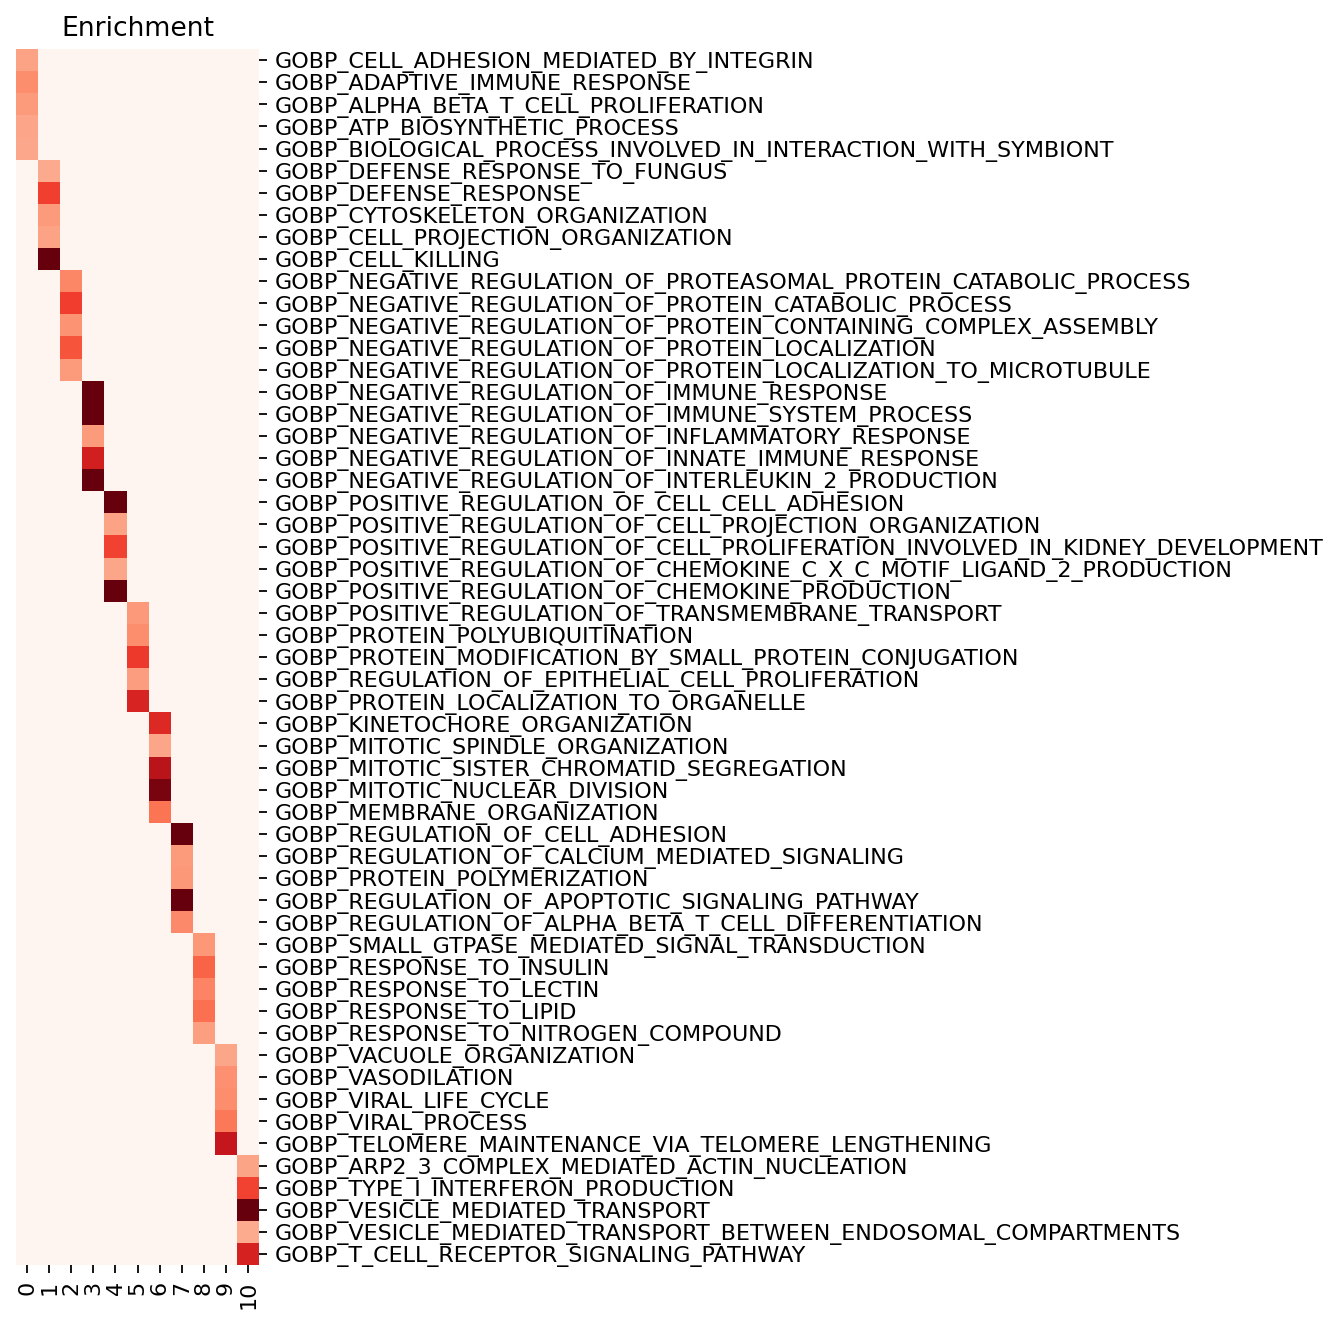

In [101]:
ax=ov.single.pathway_enrichment_plot(res,plot_title='Enrichment',cmap='Reds',
                                         xticklabels=True,cbar=False,square=True,vmax=10,
                                         yticklabels=True,cbar_kws={'label': '-log10(qvalue)','shrink': 0.5,})
ax.grid(False)

In [102]:
# Assuming Res is your DataFrame
output_file = "/home/lugli/spuccio/Projects/SP039/New_2024/go_bp.xlsx"

with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
    for cluster, df_cluster in res.groupby("Cluster"):
        # Make sure sheet name is valid
        sheet_name = f"cluster_{str(cluster)}"
        df_cluster.to_excel(writer, sheet_name=sheet_name, index=False)

print(f"Custom enrichment results saved to {output_file}")


Custom enrichment results saved to /home/lugli/spuccio/Projects/SP039/New_2024/go_bp.xlsx


# Wikipathway

In [103]:
pathway_dict=ov.utils.geneset_prepare('/home/lugli/spuccio/Projects/SP039/New_2024/MSigDB/c2.cp.wikipathways.v2024.1.Hs.symbols.gmt',organism='Human')


In [104]:
res=ov.single.pathway_enrichment(adata,pathways_dict=pathway_dict,organism='Human',cutoff=0.05,logfc_threshold=1,
                                     group_by='leiden',plot=False)

In [105]:
res['cluster2'] = res['Cluster'].astype(int)
res = res.sort_values(['cluster2'])
del res['cluster2']

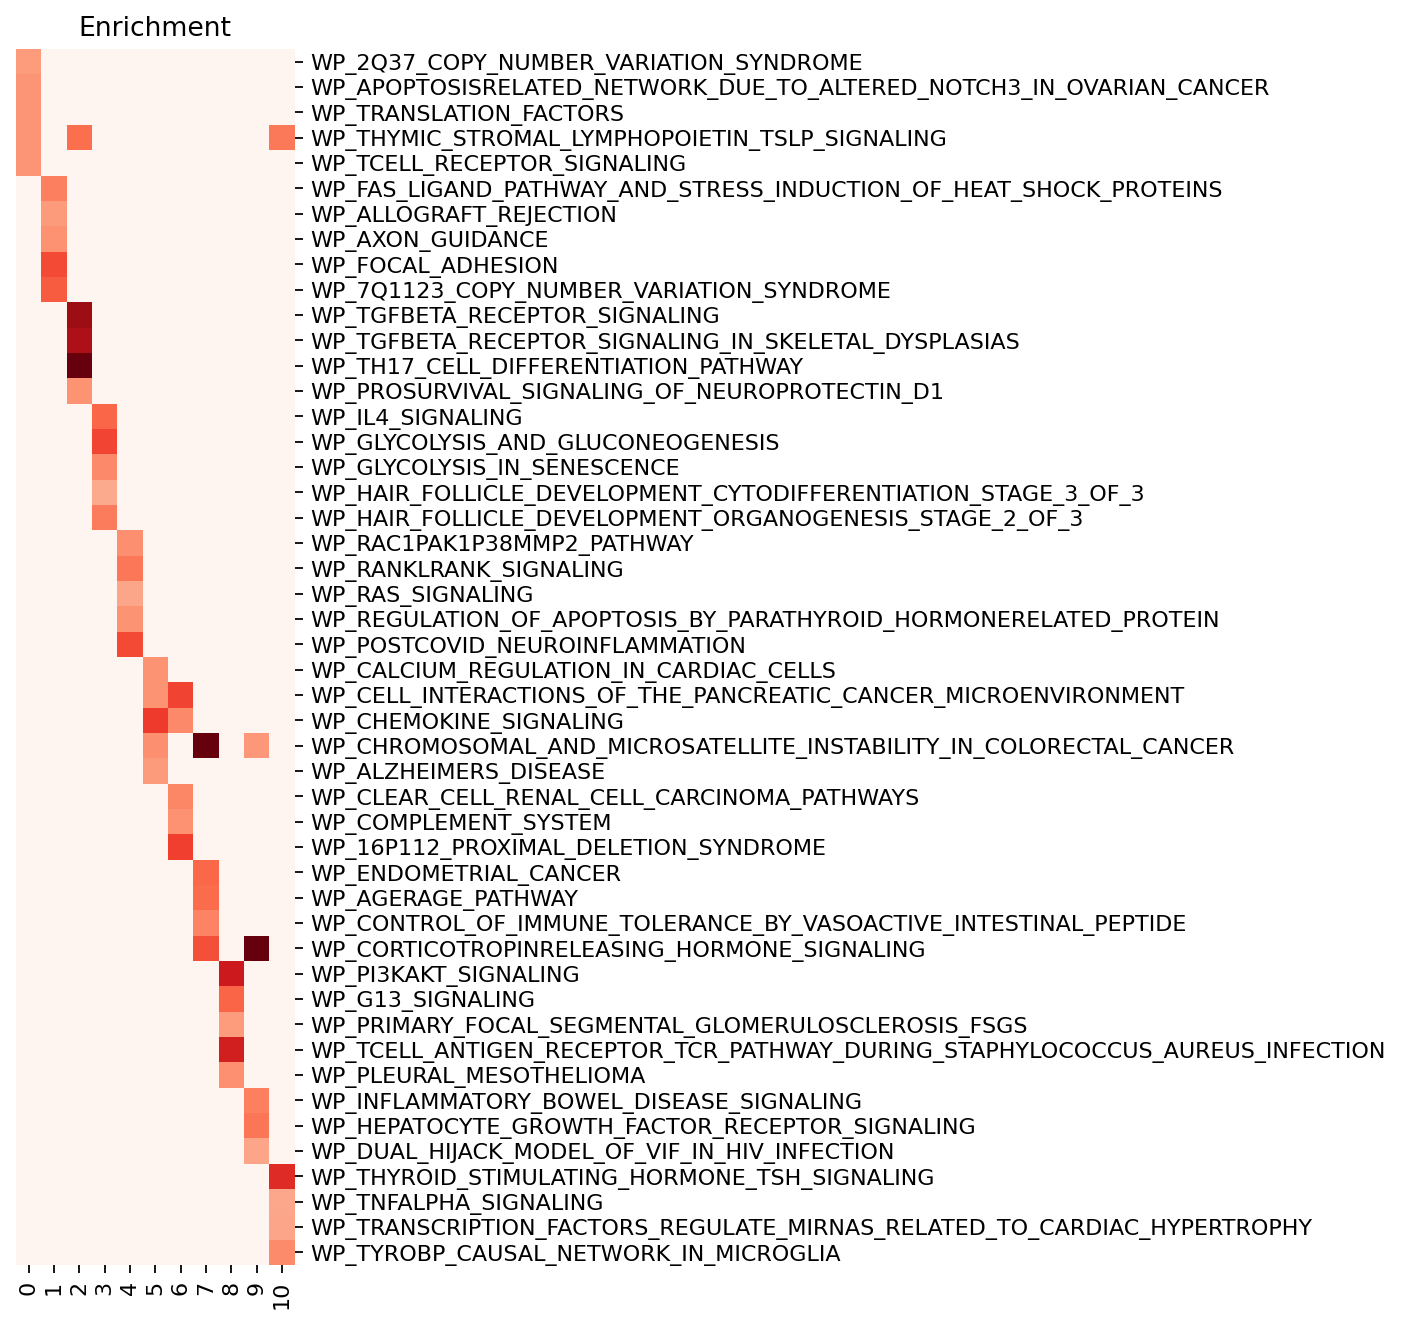

In [106]:
ax=ov.single.pathway_enrichment_plot(res,plot_title='Enrichment',cmap='Reds',
                                         xticklabels=True,cbar=False,square=True,vmax=10,
                                         yticklabels=True,cbar_kws={'label': '-log10(qvalue)','shrink': 0.5,})
ax.grid(False)

In [107]:
# Assuming Res is your DataFrame
output_file = "/home/lugli/spuccio/Projects/SP039/New_2024/Wikipathway.xlsx"

with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
    for cluster, df_cluster in res.groupby("Cluster"):
        # Make sure sheet name is valid
        sheet_name = f"cluster_{str(cluster)}"
        df_cluster.to_excel(writer, sheet_name=sheet_name, index=False)

print(f"Custom enrichment results saved to {output_file}")


Custom enrichment results saved to /home/lugli/spuccio/Projects/SP039/New_2024/Wikipathway.xlsx
